In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
import matplotlib as mpl
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    #ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [4]:
def Inductor(deg,N, airgap=0.025, thin=False):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    if not thin:
        M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
        M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [5]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
f = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}
Keys = ['C1','C2','Fe','Air']

In [6]:
# M = Inductor(2,3, airgap=0.025)
# M.plotmesh(figsize=(20,20),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, knots=1, bwidth=0.01, patch_idx=0)
# # r=0.08
# # plt.gca().add_patch(plt.Circle((0.375, 0.5), r, fill=False))
# # plt.plot(0.375, 0.5, 'o', color="black")
# # plt.gca().add_patch(plt.Circle((1.125, 0.5), r, fill=False))
# # plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5+r/np.sqrt(2), 0.5-r/np.sqrt(2)], color="black")
# # plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5-r/np.sqrt(2),0.5+r/np.sqrt(2)], color="black")
# # #plt.plot([0, 0], [-r, r])  # vertical
# plt.axis('off');
# plt.axis('scaled');
# #plt.show()
# plt.savefig('/mnt/c/Users/stefa/Pictures/Inductor_mesh.pdf',bbox_inches='tight');

In [19]:
degs = (5,)
maxpatches =(15000,)
#maxiter=(7,7,7,6)
maxiter=(3,)
eps=(1e-8,)
plot=1
uniform=0
thin = False

R = np.zeros((max(maxiter),len(degs)*7))

for i,deg in enumerate(degs):
    print("#########################################")
    N = 2*deg+1
    M = Inductor(deg,N, thin=thin)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        B = (MB.B@MB.R_related.T).tocsr()
        t1 =time.time()
        Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
        R[k,i*7+5]= time.time()-t1
        Basis = scipy.sparse.hstack([MB.R_free.T, MB.R_related.T@Basis], format='csc')
        R[k,i*7+6]=time.time()-t1
        
        print(k, MB.nPatches)
        if plot:
            MB.mesh.plotmesh(figsize=(10,10),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, nodes=30, knots=0, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            plt.savefig('/mnt/c/Users/stefa/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.savefig('/home/wolfman/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary({0:0})

        Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
        Fh = np.sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys],axis=0)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        U.append(uh)
            
        # MB.plot(uh, mesh=True)
        # plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=nu, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)
        if not uniform:
            marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
            marked_patches = {p:None for p in marked_patches}
    
            if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
                break;

        if eta < eps[i]:
            break;

        if k<maxiter[i]-1:
            if not uniform:
                t = time.time()
                P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
                print('splitting took '+str(time.time()-t)+' seconds.')
            else:
                P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)

            for j in range(len(U)):
                U[j]=P@U[j]
        k+=1
        
    # P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
    # P = MB.p_refine(1, return_P = True, in_subspace=True)@P

    # dir_bcs = MB.set_fixed_boundary({0:0})

    # Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
    # Fh = np.sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys], axis=0)
    # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)

    # u_exact = LS.complete(operators.make_solver(LS.A,spd=True)@LS.b)

    #MB.plot(u_exact, mesh=True)
    #plt.show();

    # for j in range(len(U)):
    #     eh = u_exact - P@U[j]
    #     Eerr = np.sqrt(eh@Kh@eh)
    #     R[j,i*5+2] = Eerr
    #     R[j,i*5+4] = R[j,i*5+3]/Eerr
        
    # if uniform:
    #     np.save('Inductor_uniform_p'+str(deg),R)
    # else:
    #     np.save('Inductor_adaptive_p'+str(deg),R)

#########################################
setting up constraints took 0.10068440437316895 seconds.
Basis setup took 0.0028505325317382812 seconds
0 63
1.215954343676183
setting up constraints took 0.13027048110961914 seconds.
Basis setup took 0.003708362579345703 seconds
splitting took 0.21994400024414062 seconds.
1 84
0.8738066023661546
setting up constraints took 0.20159578323364258 seconds.
Basis setup took 0.005347728729248047 seconds
splitting took 0.36873888969421387 seconds.
2 126
0.6191797291529414


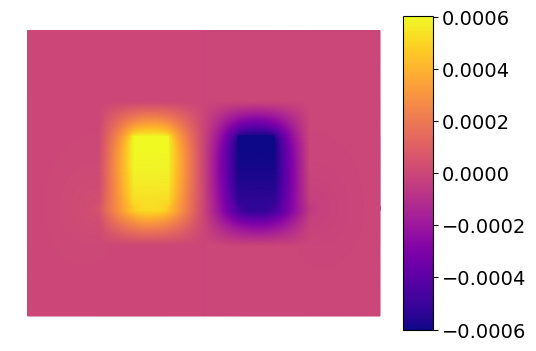

In [20]:
ax = MB.plot(uh,cmap='plasma')
ax.axis('off');
plt.savefig('Inductor_uh.png',bbox_inches='tight',dpi=300)
plt.show()

/tmp/ipykernel_353/3379247139.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=MAX, vmin=MIN, cmap='plasma',shading='auto')


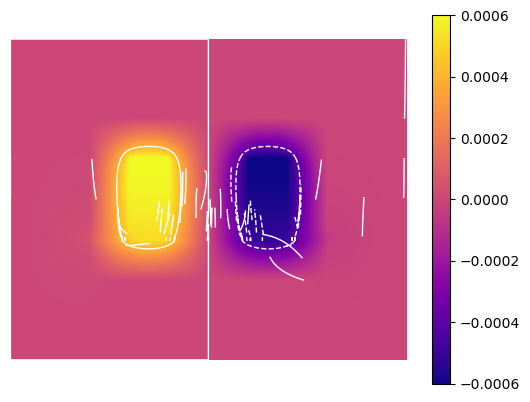

In [23]:
#plot uh field
res=(100,100)

u = MB.Basis@uh
MAX=u.max()
MIN=u.min()
X_full=[]
Y_full=[]
data_full = []
n = MB.mesh.numpatches

for p in range(n):
    kvs=MB.mesh.kvs[p]
    geo=MB.mesh.geos[p]
    u_p = u[MB.N_ofs[p]:MB.N_ofs[p+1]]
    u_func = bspline.BSplineFunc(kvs=kvs, coeffs=u_p)
    #u_grad = geometry.BSplineFunc(kvs, u_p).transformed_jacobian(geo)
    grd = tuple(np.linspace(s[0], s[1], r) for (s,r) in zip(geo.support, res))
    XY = utils.grid_eval(geo, grd)
    data = u_func.grid_eval(grd)
    #data = np.linalg.norm(data,axis=2)
    plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=MAX, vmin=MIN, cmap='plasma',shading='auto')

    X_full.append(XY[...,0])
    Y_full.append(XY[...,1])
    data_full.append(data)
    #plot.set_edgecolor('face')
    plot.set_rasterized(True)

    plt.axis('scaled');
    plt.axis('off');
    #print(data.shape)
    #vis.plot_quiver(lambda x,y: (uy(x,y),-ux(x,y)) , geo=geo, res=3)
    #vis.plot_field(lambda x,y: np.sqrt(u_grad(x,y)[0]**2+u_grad(x,y)[1]**2), geo=geo,vmin = u_min, vmax=u_max)
    #vis.plot_field(u, geo=geo, vmin = u_min, vmax=u_max)

X_full = np.concatenate([X_full[i][:, :-1] for i in range(n-1)] + [X_full[-1]], axis=1)
Y_full = np.concatenate([Y_full[i][:, :-1] for i in range(n-1)] + [Y_full[-1]], axis=1)
data_full = np.concatenate([data_full[i][:, :-1] for i in range(n-1)] + [data_full[-1]], axis=1)
plt.colorbar();
plt.contour(X_full, Y_full, data_full,colors='white', levels=3, linewidths=1)
plt.savefig('Inductor_uh.pdf',bbox_inches='tight',dpi=1200);
plt.show()
#print(MAX)

/tmp/ipykernel_5115/1122427620.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=0.01, vmin=0, cmap='plasma',shading='auto')


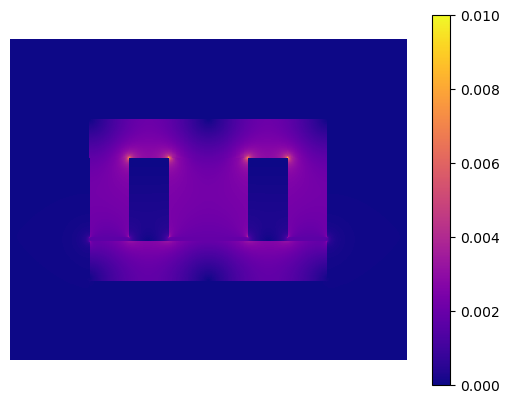

In [52]:
#plot B field
res=(100,100)

u = MB.Basis@uh
MAX=0
X_full=[]
Y_full=[]
data_full = []
n = MB.mesh.numpatches

for p in range(n):
    kvs=MB.mesh.kvs[p]
    geo=MB.mesh.geos[p]
    u_p = u[MB.N_ofs[p]:MB.N_ofs[p+1]]
    u_func = bspline.BSplineFunc(kvs=kvs, coeffs=u_p)
    u_grad = geometry.BSplineFunc(kvs, u_p).transformed_jacobian(geo)
    grd = tuple(np.linspace(s[0], s[1], r) for (s,r) in zip(geo.support, res))
    XY = utils.grid_eval(geo, grd)
    data = u_grad.grid_eval(grd)
    data = np.linalg.norm(data,axis=2)
    MAX=max(MAX, np.max(data))

    #print(XY[...,0].shape)
for p in range(n):
    kvs=MB.mesh.kvs[p]
    geo=MB.mesh.geos[p]
    u_p = u[MB.N_ofs[p]:MB.N_ofs[p+1]]
    u_func = bspline.BSplineFunc(kvs=kvs, coeffs=u_p)
    u_grad = geometry.BSplineFunc(kvs, u_p).transformed_jacobian(geo)
    grd = tuple(np.linspace(s[0], s[1], r) for (s,r) in zip(geo.support, res))
    XY = utils.grid_eval(geo, grd)
    data = u_grad.grid_eval(grd)
    data = np.linalg.norm(data,axis=2)
    plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=0.01, vmin=0, cmap='plasma',shading='auto')

    X_full.append(XY[...,0])
    Y_full.append(XY[...,1])
    data_full.append(data)
    #plot.set_edgecolor('face')
    plot.set_rasterized(True)

    plt.axis('scaled');
    plt.axis('off');
    #print(data.shape)
    #vis.plot_quiver(lambda x,y: (uy(x,y),-ux(x,y)) , geo=geo, res=3)
    #vis.plot_field(lambda x,y: np.sqrt(u_grad(x,y)[0]**2+u_grad(x,y)[1]**2), geo=geo,vmin = u_min, vmax=u_max)
    #vis.plot_field(u, geo=geo, vmin = u_min, vmax=u_max)

X_full = np.concatenate([X_full[i][:, :-1] for i in range(n-1)] + [X_full[-1]], axis=1)
Y_full = np.concatenate([Y_full[i][:, :-1] for i in range(n-1)] + [Y_full[-1]], axis=1)
data_full = np.concatenate([data_full[i][:, :-1] for i in range(n-1)] + [data_full[-1]], axis=1)
plt.colorbar();
#plt.contour(X_full, Y_full, data_full, vmax=0.02, vmin=0,colors='white', levels=100, linewidths=0.5)
plt.savefig('Inductor_B.pdf',bbox_inches='tight',dpi=1200);
plt.show()
#print(MAX)

/tmp/ipykernel_5115/2994691211.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=3000, vmin=0, cmap='plasma')


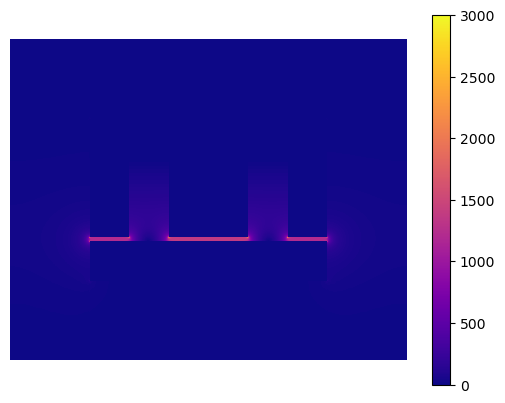

11274.697299566205


In [51]:
#plot H field
res=(100,100)

u = MB.Basis@uh
MAX=0
X_full=[]
Y_full=[]
data_full = []
n = MB.mesh.numpatches

for p in range(n):
    kvs=MB.mesh.kvs[p]
    geo=MB.mesh.geos[p]
    u_p = u[MB.N_ofs[p]:MB.N_ofs[p+1]]
    u_func = bspline.BSplineFunc(kvs=kvs, coeffs=u_p)
    u_grad = geometry.BSplineFunc(kvs, u_p).transformed_jacobian(geo)
    grd = tuple(np.linspace(s[0], s[1], r) for (s,r) in zip(geo.support, res))
    XY = utils.grid_eval(geo, grd)
    data = nu[MB.mesh.patch_domains[p]]*u_grad.grid_eval(grd)
    data = np.linalg.norm(data,axis=2)
    MAX=max(MAX, np.max(data))

    #print(XY[...,0].shape)

    plot=plt.pcolormesh(XY[...,0], XY[...,1], data, vmax=3000, vmin=0, cmap='plasma')

    X_full.append(XY[...,0])
    Y_full.append(XY[...,1])
    data_full.append(data)
    #plot.set_edgecolor('face')
    plot.set_rasterized(True)

    plt.axis('scaled');
    plt.axis('off');
    #print(data.shape)
    #vis.plot_quiver(lambda x,y: (uy(x,y),-ux(x,y)) , geo=geo, res=3)
    #vis.plot_field(lambda x,y: np.sqrt(u_grad(x,y)[0]**2+u_grad(x,y)[1]**2), geo=geo,vmin = u_min, vmax=u_max)
    #vis.plot_field(u, geo=geo, vmin = u_min, vmax=u_max)

X_full = np.concatenate([X_full[i][:, :-1] for i in range(n-1)] + [X_full[-1]], axis=1)
Y_full = np.concatenate([Y_full[i][:, :-1] for i in range(n-1)] + [Y_full[-1]], axis=1)
data_full = np.concatenate([data_full[i][:, :-1] for i in range(n-1)] + [data_full[-1]], axis=1)

plt.colorbar();
#plt.contour(X_full, Y_full, data_full, vmax=2000, vmin=0,colors='white', levels=70, linewidths=0.5)

plt.savefig('Inductor_H.pdf',bbox_inches='tight',dpi=1200);
plt.show()
print(MAX)

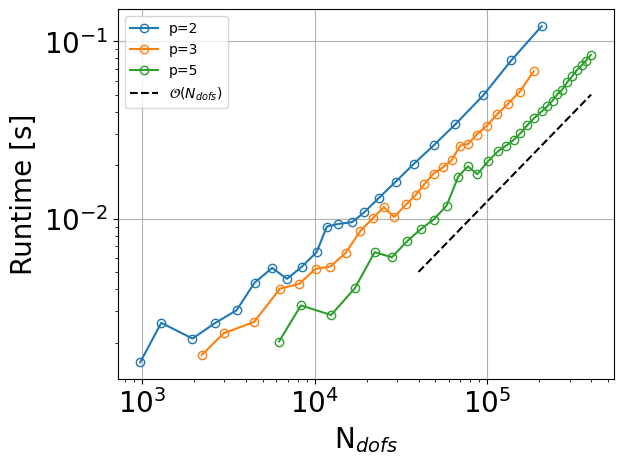

In [10]:
R2 = np.load('Inductor_adaptive_p2.npy')
R3 = np.load('Inductor_adaptive_p3.npy')
R5 = np.load('Inductor_adaptive_p5.npy')


plt.loglog(R2[:,0], R2[:,6], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,6], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R5[:,0], R5[:,6], "o-", label="p=5",markerfacecolor='none')


# reference O(N) line
x = 4*1e4
y = 5*1e-3
l=1
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--",color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.savefig('Inductor_runtime_adaptive.pdf', bbox_inches='tight')

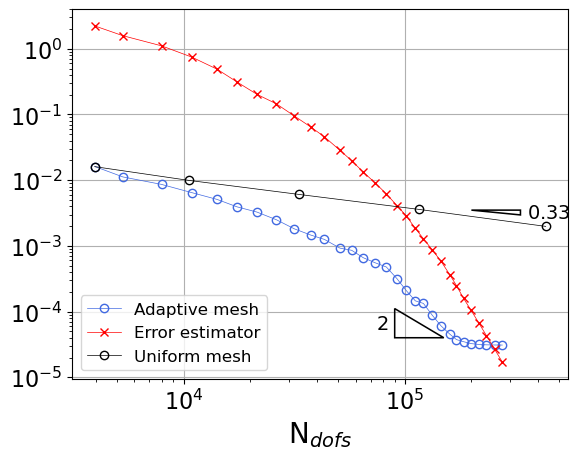

In [8]:
#R_a = np.load('Inductor_adaptive.npy')
#R_u = np.load('Inductor_uniform.npy')

# numdofs=R_u[:,0]
# # numdofs_a = R_a[:,0]
# Eerr = R_u[:,2]
# # Eerr_a = R_a[:,2]
pos=((1.5*1e5,4*1e-5),(2*1e5,4*1e-6),(4*1e5,5*1e-7))
pos_u=((2*1e5,3.5*1e-3),(1e5,6*1e-3),(2*1e5,3*1e-3))
w = (1.0,1.0,1.0)
inv = (True,True,True)
for i, deg in enumerate((4,)):
    R_a = np.load('Inductor_adaptive_p'+str(deg)+'.npy')
    R_u = np.load('Inductor_uniform_p'+str(deg)+'.npy')
    
    numdofs=R_u[:,0]
    numdofs_a = R_a[:,0]

    Eerr = R_u[:,2]
    Eerr_a = R_a[:,2]

    Eta = R_a[:,3]

    # print(R_a[:,4])

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]

    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]

    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Inductorp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

In [7]:
deg=4
M = Inductor(deg,deg+1)
MB = assemble.MultiBasis(M, subspace='C0')

maxiter=8 #p2: 10 #p3: 9 #p4: 8
R=np.zeros((maxiter,3))
for i in range(maxiter):
    M.h_refine(-1);
    MB = assemble.MultiBasis(M)

    t=time.time()
    B=MB.set_constraints(subspace='C0')
    R[i,0] = MB.nLocDofs
    R[i,1] = time.time()-t

    I = np.unique(B.indices)
    F = np.setdiff1d(np.arange(MB.N_ofs[-1]),I)

    R_related = scipy.sparse.coo_matrix((np.ones(len(I)),(np.arange(len(I)),I)),shape=(len(I),MB.N_ofs[-1]))
    R_free = scipy.sparse.coo_matrix((np.ones(len(F)),(np.arange(len(F)),F)),shape=(len(F),MB.N_ofs[-1]))
    
    B = (MB.B@R_related.T).tocsr()
    t1 =time.time()
    Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
    Basis = scipy.sparse.hstack([R_free.T, R_related.T@Basis], format='csc')
    R[i,2]=time.time()-t1

np.save('Inductor_runtime_uniform_p'+str(deg),R)

setting up constraints took 0.10515546798706055 seconds.
Basis setup took 0.003030538558959961 seconds
setting up constraints took 0.10442590713500977 seconds.
setting up constraints took 0.1135704517364502 seconds.
setting up constraints took 0.1224360466003418 seconds.
setting up constraints took 0.1582334041595459 seconds.
setting up constraints took 0.25267505645751953 seconds.
setting up constraints took 0.5392074584960938 seconds.
setting up constraints took 1.6787092685699463 seconds.
setting up constraints took 6.344122648239136 seconds.


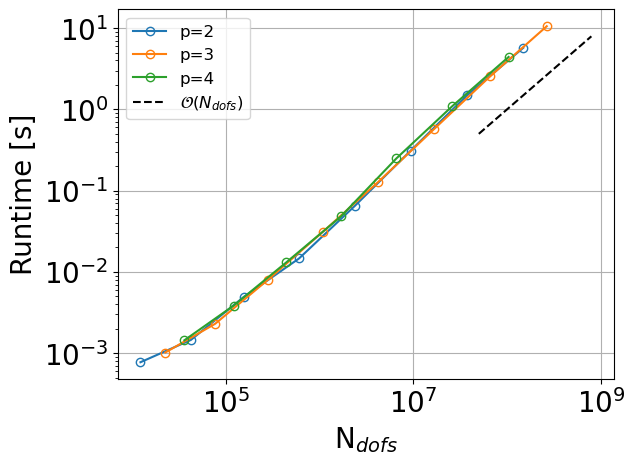

In [8]:
R2 = np.load('Inductor_runtime_uniform_p2.npy')
R3 = np.load('Inductor_runtime_uniform_p3.npy')
R4 = np.load('Inductor_runtime_uniform_p4.npy')

plt.loglog(R2[:,0], R2[:,2], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,2], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R4[:,0], R4[:,2], "o-", label="p=4",markerfacecolor='none')

# reference O(N) line
x = 5*1e7
y = 5*1e-1
l=1.2
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--", color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend(loc='upper left',prop={'size': 12})
plt.grid(True)
plt.savefig('Inductor_runtime_uniform.pdf', bbox_inches='tight')